In [1]:
import pandas as pd

In [15]:
data=pd.read_csv('finenc_data')

In [17]:
X=data.iloc[:,[1,3,4,5,6,7,8,9,10,11,12]]
X

,passenger_count,distance_km,Duration,RatecodeID_1,RatecodeID_2,payment_type_1,payment_type_2,AM,PM,weekday_1,weekday_3
0,3,9.046547,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1,1.279013,5.283333,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,2,3.755555,15.683333,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,2,3.251549,6.533333,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1,5.794492,15.700000,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
183276,1,3.806279,23.266667,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
183277,1,3.496576,22.750000,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
183278,1,0.580119,2.683333,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
183279,2,1.555737,7.150000,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [18]:
y=data.iloc[:,2]
y=pd.DataFrame(y)
y

,total_amount
0,41.62
1,8.16
2,15.30
3,11.16
4,16.30
...,...
183276,20.16
183277,18.30
183278,4.80
183279,7.80


In [6]:
from sklearn.model_selection import train_test_split

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [20]:
X_train.shape

(128296, 11)

In [21]:
X_test.shape

(54985, 11)

In [22]:
y_train.shape

(128296, 1)

In [ ]:
LINEAR REGRESSION:

In [23]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [24]:
LR.fit(X_train,y_train)

LinearRegression()

In [30]:
y_pred=LR.predict(X_test)

In [25]:
LR.score(X_train,y_train)

0.883941535965434

In [26]:
LR.score(X_test,y_test)

0.9043949725713805

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [31]:
mean_absolute_error(y_test, y_pred)

1.3511638441343379

In [32]:
mean_squared_error(y_test, y_pred)

6.940750346938188

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'PREDICTED DATA')

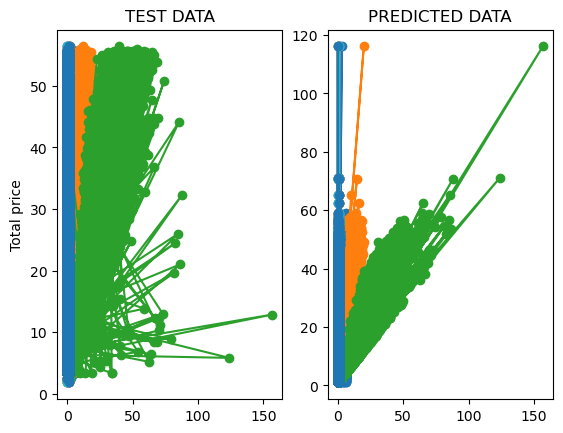

In [40]:
plt.subplot(1, 2, 1)
plt.plot(X_test,y_test,'-o')
plt.ylabel('Total price')
plt.title("TEST DATA")
plt.subplot(1, 2, 2)
plt.plot(X_test,y_pred,'-o')
plt.title("PREDICTED DATA")

In [ ]:
LASSO:

In [41]:
from sklearn.linear_model import Lasso

In [42]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [43]:
lasso.score(X_train,y_train)

0.8832116973191092

In [44]:
lasso.score(X_test,y_test)

0.9029484144784

In [45]:
y_pred_l=lasso.predict(X_test)

Text(0.5, 1.0, 'PREDICTED DATA')

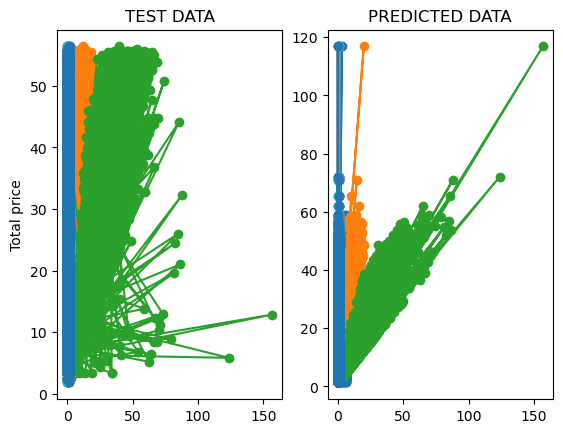

In [46]:
plt.subplot(1, 2, 1)
plt.plot(X_test,y_test,'-o')
plt.ylabel('Total price')
plt.title("TEST DATA")
plt.subplot(1, 2, 2)
plt.plot(X_test,y_pred_l,'-o')
plt.title("PREDICTED DATA")

In [ ]:
RIDGE:

In [47]:
from sklearn.linear_model import Ridge

In [48]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

Ridge()

In [49]:
ri_pred=ridge.predict(X_test)

In [50]:
ridge.score(X_train,y_train)

0.8839415258157419

In [51]:
ridge.score(X_test,y_test)

0.9043945418502771

In [52]:
mean_absolute_error(y_test, ri_pred)

1.351143537828655

In [53]:
mean_squared_error(y_test,ri_pred)

6.940781616503482

Text(0.5, 1.0, 'PREDICTED DATA')

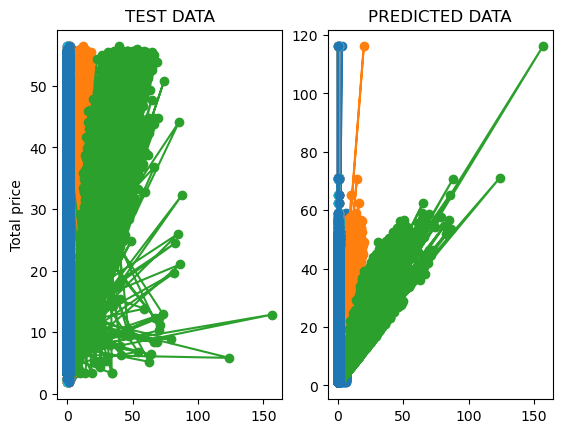

In [54]:
plt.subplot(1, 2, 1)
plt.plot(X_test,y_test,'-o')
plt.ylabel('Total price')
plt.title("TEST DATA")
plt.subplot(1, 2, 2)
plt.plot(X_test,ri_pred,'-o')
plt.title("PREDICTED DATA")

In [ ]:
KNN REGRESSION

In [55]:
from sklearn.neighbors import KNeighborsRegressor

In [56]:
knn = KNeighborsRegressor(n_neighbors=3) 
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [57]:
k_pred=knn.predict(X_test)

In [58]:
knn.score(X_train,y_train)

0.9656880703303116

In [59]:
knn.score(X_test,y_test)

0.9323137160929097

In [60]:
mean_absolute_error(y_test,k_pred)

1.1009606256251703

Text(0.5, 1.0, 'PREDICTED DATA')

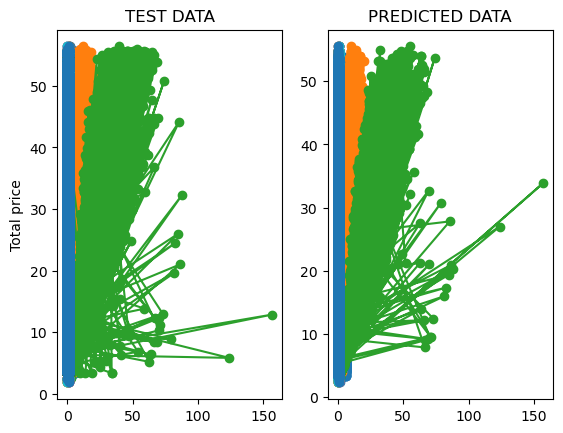

In [61]:
plt.subplot(1, 2, 1)
plt.plot(X_test,y_test,'-o')
plt.ylabel('Total price')
plt.title("TEST DATA")
plt.subplot(1, 2, 2)
plt.plot(X_test,k_pred,'-o')
plt.title("PREDICTED DATA")

In [ ]:
HYPERPARAMETER TUNING:

In [71]:
import numpy as np
param_dist={'n_neighbors': np.arange(1, 10), 'weights': ['uniform', 'distance']}

In [72]:
from sklearn.model_selection import RandomizedSearchCV

In [73]:
RSC=RandomizedSearchCV(estimator=knn, param_distributions=param_dist,cv=5,random_state=42)

In [74]:
RSC.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(n_neighbors=3),
                   param_distributions={'n_neighbors': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'weights': ['uniform', 'distance']},
                   random_state=42)

In [75]:
RSC.score(X_train,y_train)

0.9538208075793844

In [93]:
RSC.score(X_test,y_test)

0.9429286217167315

In [77]:
RSC.best_params_

{'weights': 'uniform', 'n_neighbors': 9}

In [78]:
RSC.best_estimator_

KNeighborsRegressor(n_neighbors=9)

In [ ]:
DECISION TREE

In [62]:
from sklearn.tree import DecisionTreeRegressor

In [63]:
DT=DecisionTreeRegressor(max_depth=5,random_state=0)

In [64]:
DT.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, random_state=0)

In [68]:
d_pred=DT.predict(X_test)

In [65]:
DT.score(X_train,y_train)

0.9224119284184895

In [66]:
DT.score(X_test,y_test)

0.9210796813127784

Text(0.5, 1.0, 'PREDICTED DATA')

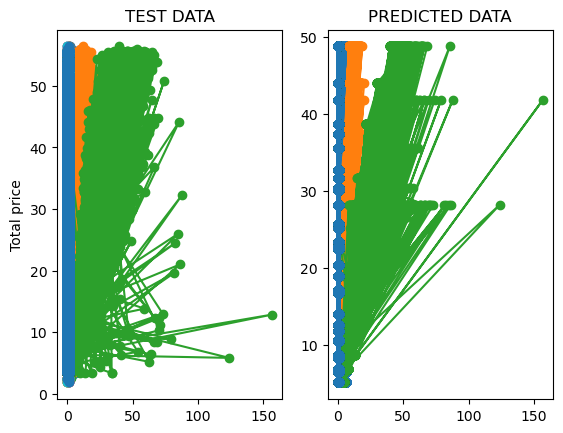

In [69]:
plt.subplot(1, 2, 1)
plt.plot(X_test,y_test,'-o')
plt.ylabel('Total price')
plt.title("TEST DATA")
plt.subplot(1, 2, 2)
plt.plot(X_test,d_pred,'-o')
plt.title("PREDICTED DATA")

In [86]:
from scipy.stats import randint
param_dist={
    "splitter": ["best", "random"],
    "max_depth": randint(1, 20),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20)}

In [87]:
RF= RandomizedSearchCV(estimator=DT,param_distributions=param_dist,
    n_iter=100, 
    cv=5, 
    random_state=42)

In [88]:
RF.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeRegressor(max_depth=5, random_state=0),
                   n_iter=100,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000158074043E0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001581FABA9C0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001581FABA090>,
                                        'splitter': ['best', 'random']},
                   random_state=42)

In [89]:
RF.score(X_train,y_train)

0.9537344383957391

In [91]:
RF.best_params_

{'max_depth': 11,
 'min_samples_leaf': 16,
 'min_samples_split': 17,
 'splitter': 'best'}

In [92]:
RF.best_estimator_

DecisionTreeRegressor(max_depth=11, min_samples_leaf=16, min_samples_split=17,
                      random_state=0)